In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve )

In [3]:
df = pd.read_csv("diabetic_data.csv")

In [5]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
df.shape

(101766, 50)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [9]:
# --------------------------------------------------------- # 3. Create Target Variable # --------------------------------------------------------- # The original dataset has three values: # # NO -> patient was not readmitted # <30 -> patient was readmitted within 30 days # >30 -> patient was readmitted after 30 days # # For this assignment we are predicting 30-day readmission. # # 1 = readmitted within 30 days # 0 = not readmitted within 30 days 
df["readmitted_30"] = (df["readmitted"] == "<30").astype(int) 
print("\nTarget distribution:") 
print(df["readmitted_30"].value_counts())


Target distribution:
readmitted_30
0    90409
1    11357
Name: count, dtype: int64


In [10]:
columns_to_remove = [ "encounter_id", "patient_nbr", "readmitted" ]
df = df.drop(columns=columns_to_remove, errors="ignore")

In [15]:
df = df.replace("?",np.nan)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    101766 non-null  object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                101766 non-null  object
 9   medical_specialty         101766 non-null  object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [ ]:
features = [ "age", "gender", "race", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses", "admission_type_id", "discharge_disposition_id", "admission_source_id", "A1Cresult", "insulin", "diabetesMed", "diag_1", "diag_2", "diag_3" ]


20


In [23]:
X = df[features]
y = df["readmitted_30"]

In [24]:
X.shape,y.shape

((101766, 20), (101766,))

In [25]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [26]:
numerical_columns = X.select_dtypes( include=["int64", "float64"] ).columns.tolist()
categorical_columns = X.select_dtypes( include=["object"] ).columns.tolist()

In [27]:
print("\nNumerical columns:")
print(numerical_columns)


Numerical columns:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


In [28]:
print("\nCategorical columns:")
print(categorical_columns)


Categorical columns:
['age', 'gender', 'race', 'A1Cresult', 'insulin', 'diabetesMed', 'diag_1', 'diag_2', 'diag_3']


In [29]:
numeric_pipeline = Pipeline( steps=[ ("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()) ] )

In [30]:
categorical_pipeline = Pipeline( steps=[ ("imputer", SimpleImputer(strategy="most_frequent")), ( "onehot", OneHotEncoder( handle_unknown="ignore" ) ) ] )

In [31]:
preprocessor = ColumnTransformer( transformers=[ ("numeric", numeric_pipeline, numerical_columns), ("categorical", categorical_pipeline, categorical_columns) ] )

In [32]:
model = LogisticRegression( penalty="l2", C=1.0, max_iter=1000, solver="liblinear" )

In [33]:
pipeline = Pipeline( steps=[ ("preprocessing", preprocessor), ("model", model) ] )

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y )

In [35]:
print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 81412
Testing samples: 20354


In [36]:
print("\nTraining Logistic Regression model...")
pipeline.fit(X_train, y_train)
print("Model training completed.")


Training Logistic Regression model...
Model training completed.


In [37]:
y_pred = pipeline.predict(X_test)

In [38]:
y_probability = pipeline.predict_proba(X_test)[:, 1]

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score( y_test, y_pred, zero_division=0 )
recall = recall_score( y_test, y_pred, zero_division=0 )
f1 = f1_score( y_test, y_pred, zero_division=0 )
roc_auc = roc_auc_score( y_test, y_probability )
print("\n-----------------------------------")
print("MODEL EVALUATION")
print("-----------------------------------")
print("Accuracy :", round(accuracy, 4)*100)
print("Precision:", round(precision, 4)*100)
print("Recall :", round(recall, 4)*100)
print("F1 Score :", round(f1, 4)*100)
print("ROC-AUC :", round(roc_auc, 4)*100)


-----------------------------------
MODEL EVALUATION
-----------------------------------
Accuracy : 88.84
Precision: 50.0
Recall : 2.03
F1 Score : 3.8899999999999997
ROC-AUC : 64.4


In [41]:
print("\nClassification Report:")
print( classification_report( y_test, y_pred, zero_division=0 ) )


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.50      0.02      0.04      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.51      0.49     20354
weighted avg       0.85      0.89      0.84     20354




Confusion Matrix:
[[18037    46]
 [ 2225    46]]


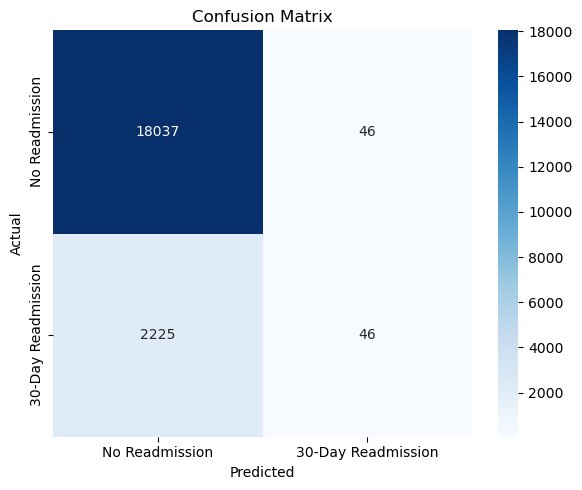

In [42]:
cm = confusion_matrix( y_test, y_pred )
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6, 5))
sns.heatmap( cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Readmission", "30-Day Readmission"], yticklabels=["No Readmission", "30-Day Readmission"] )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

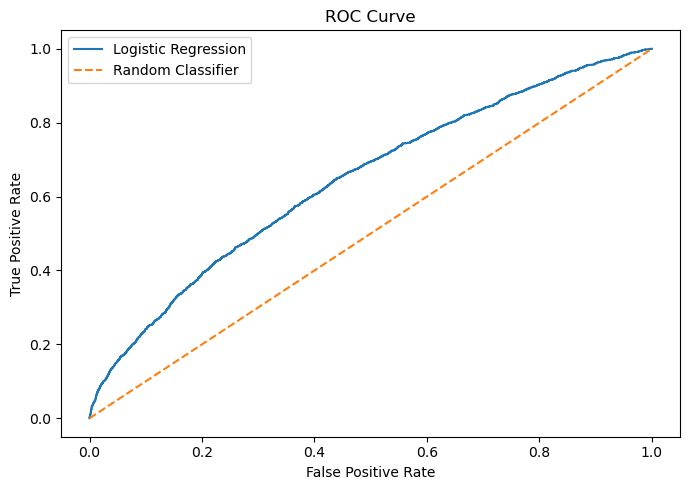

In [43]:
fpr, tpr, thresholds = roc_curve( y_test, y_probability )
plt.figure(figsize=(7, 5))
plt.plot( fpr, tpr, label="Logistic Regression" )
plt.plot( [0, 1], [0, 1], linestyle="--", label="Random Classifier" )
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
print("\nROC-AUC Score:", round(roc_auc, 4))


ROC-AUC Score: 0.644
